# Phase 2: Exploratory Data Analysis (EDA)


In [1]:
# Import libraries 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Upload dataset
import pandas as pd
data = pd.read_csv('/Users/AndreaLopera/Desktop/Data Science Portfolio/Procurement-Intelligence-Dashboard-main/data/synthetic_procurement_orders.csv') 
data.head()

,order_date,po_id,supplier_id,supplier_region,supplier_country,part_id,part_type,category,unit_of_measure,quantity,unit_cost_usd,total_cost_usd,promised_lead_time_days,actual_lead_time_days,on_time_flag,defect_flag,defect_reason
0,2023-01-01,PO-ca224457,SU-006,South America,Brazil,PART-c315bc59,Blade,Attachments,ea,3,5926.57,17779.71,44,42,1,1,Packaging Issue
1,2023-01-01,PO-a5333bd5,SU-007,Europe,Netherlands,PART-5edada95,Hydraulic Fluid,Lubricants & Fluids,gal,50,22.99,1149.50,5,5,1,0,No Defect
2,2023-01-01,PO-14fcbbc9,SU-012,North America,USA,PART-4e8d7802,Transmission Oil,Lubricants & Fluids,gal,102,23.09,2355.18,6,6,1,0,No Defect
3,2023-01-01,PO-a6e86824,SU-010,Asia,South Korea,PART-7c205b95,Steel Plate,Steel,lb,574,0.63,361.62,25,25,1,0,No Defect
4,2023-01-01,PO-71787423,SU-007,Europe,Netherlands,PART-4e8d7802,Transmission Oil,Lubricants & Fluids,gal,153,23.55,3603.15,5,4,1,0,No Defect


In [3]:
# Get familiar with the features
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9750 entries, 0 to 9749
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   order_date               9750 non-null   object 
 1   po_id                    9750 non-null   object 
 2   supplier_id              9750 non-null   object 
 3   supplier_region          9750 non-null   object 
 4   supplier_country         9750 non-null   object 
 5   part_id                  9750 non-null   object 
 6   part_type                9750 non-null   object 
 7   category                 9750 non-null   object 
 8   unit_of_measure          9750 non-null   object 
 9   quantity                 9750 non-null   int64  
 10  unit_cost_usd            9750 non-null   float64
 11  total_cost_usd           9750 non-null   float64
 12  promised_lead_time_days  9750 non-null   int64  
 13  actual_lead_time_days    9750 non-null   int64  
 14  on_time_flag            

In [4]:
# Look for null values 
data.isnull().sum(0)

order_date                 0
po_id                      0
supplier_id                0
supplier_region            0
supplier_country           0
part_id                    0
part_type                  0
category                   0
unit_of_measure            0
quantity                   0
unit_cost_usd              0
total_cost_usd             0
promised_lead_time_days    0
actual_lead_time_days      0
on_time_flag               0
defect_flag                0
defect_reason              0
dtype: int64

Note: The feature "defect_reason" has nulls as the result for the field "defect_flag" having 0 for their value. That's to say, no defect was found so there is no defect reason.

## Procurement Overview
### 1. Supplier Order Volume
### 2. Total Supplier Spend ($)

In [5]:
# Supplier Order Volume
data.groupby(['supplier_region', 'supplier_country'])['quantity'].sum()

supplier_region  supplier_country
Asia             China                287419
                 India               1343127
                 South Korea         1318112
Europe           Germany               10853
                 Netherlands           55333
North America    Mexico                14140
                 USA                  179938
South America    Brazil                 1332
Name: quantity, dtype: int64

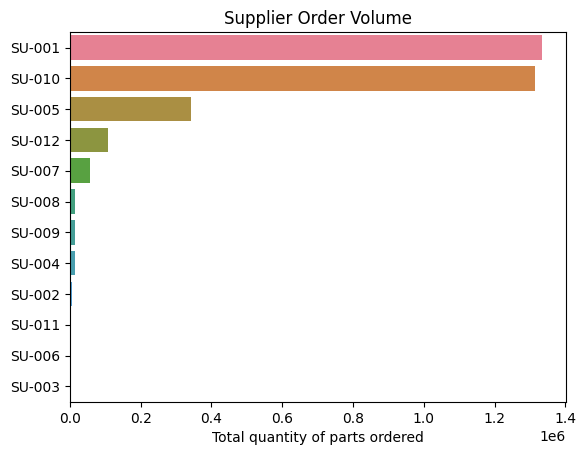

In [6]:
# Supplier Order Volume
"""
Definition: Total quantity of parts/materials ordered from each supplier.
Use: Tracks sourcing volume distribution.
Label: "Supplier Order Volume"
"""
# Gather the data
units_per_supplier = data.groupby('supplier_id')['quantity'].sum().reset_index() # type: ignore
units_per_supplier = units_per_supplier.sort_values('quantity', ascending=False)
# Plot
ax = sns.barplot(data=units_per_supplier, x='quantity', y='supplier_id', hue='supplier_id') # type: ignore
# Add a legend
plt.title("Supplier Order Volume") # type: ignore
plt.xlabel('Total quantity of parts ordered')
plt.ylabel('')
plt.show()

In [7]:
# Supplier Order Value
data.groupby(['supplier_region', 'supplier_country'])['total_cost_usd'].sum()

supplier_region  supplier_country
Asia             China               10094391.27
                 India               71371464.35
                 South Korea         45887067.01
Europe           Germany              2136629.56
                 Netherlands          1270015.99
North America    Mexico              19390808.49
                 USA                 17132963.97
South America    Brazil               5235169.74
Name: total_cost_usd, dtype: float64

In [8]:
data.groupby("supplier_id")['total_cost_usd'].sum()

supplier_id
SU-001    41853594.05
SU-002     1004789.43
SU-003     9037274.47
SU-004    17095366.64
SU-005     2426296.78
SU-006     5235169.74
SU-007     1270015.99
SU-008    12265105.64
SU-009     3205301.99
SU-010    61205097.49
SU-011    14889721.98
SU-012     3030776.18
Name: total_cost_usd, dtype: float64

In [9]:
data.groupby('defect_reason')['total_cost_usd'].sum().sum()

np.float64(172518510.38)

In [10]:
data['defect_flag'].count()

np.int64(9750)

In [11]:
(data.groupby('supplier_id')["total_cost_usd"].sum())/sum(data["total_cost_usd"])

supplier_id
SU-001    0.242603
SU-002    0.005824
SU-003    0.052384
SU-004    0.099093
SU-005    0.014064
SU-006    0.030346
SU-007    0.007362
SU-008    0.071094
SU-009    0.018579
SU-010    0.354774
SU-011    0.086308
SU-012    0.017568
Name: total_cost_usd, dtype: float64

In [12]:
data.groupby('supplier_id')["total_cost_usd"].sum().mean()

np.float64(14376542.531666666)

In [13]:
data["total_cost_usd"].sum()

np.float64(172518510.38000003)

In [14]:
# df.groupby('supplier_id')['risk_score'].mean()

In [15]:
data.groupby(["category","part_type"])['quantity'].sum()

category             part_type                  
Attachments          Blade                             700
                     Bucket                            692
                     Fork Assembly                     624
                     Ripper                            672
Cabs & Controls      Cab Glass                        4238
                     Instrument Panel                 3366
                     Joystick                         3763
                     Operator Seat                    3723
Electronics          ECM (Engine Control Module)      3148
                     GPS Module                       3268
                     Pressure Sensor                  3405
                     Temperature Sensor               3287
                     Wiring Harness                   3576
Engines              Diesel Engine                     478
                     Engine Block                      400
                     Fuel Injector                     465
       

In [16]:
data.groupby(["supplier_id", "category", "supplier_region"])["quantity"].sum()

supplier_id  category             supplier_region
SU-001       Electronics          Asia                  8415
             Steel                Asia               1326831
SU-002       Hydraulics           Europe                5065
SU-003       Engines              Asia                  1086
SU-004       Undercarriage        Asia                 13854
SU-005       Fasteners            Asia                286254
             Filters              North America        56629
SU-006       Attachments          South America         1332
SU-007       Lubricants & Fluids  Europe               55333
SU-008       Cabs & Controls      North America        15090
SU-009       Electronics          Asia                  8269
             Hydraulics           Europe                5788
SU-010       Steel                Asia               1301428
             Undercarriage        North America        14140
SU-011       Attachments          Asia                  1356
             Engines              A

In [20]:
# as-of merge to add risk scores
import pandas as pd

# Paths to orders and risk scores
PATH_ORDERS = "/Users/AndreaLopera/Desktop/Data Science Portfolio/Procurement-Intelligence-Dashboard-main/data/synthetic_procurement_orders.csv"
PATH_SCORES = "/Users/AndreaLopera/Desktop/Data Science Portfolio/Procurement-Intelligence-Dashboard-main/data/supplier_risk_scores_monthly.csv"
PATH_OUT    = "/Users/AndreaLopera/Desktop/Data Science Portfolio/Procurement-Intelligence-Dashboard-main/data/orders_with_risk_score.csv"

# Load both files
orders = pd.read_csv(PATH_ORDERS)
scores = pd.read_csv(PATH_SCORES)

# prep
orders["order_date"] = pd.to_datetime(orders["order_date"])
orders["order_month_start"] = orders["order_date"].dt.to_period("M").dt.to_timestamp()
scores["score_month"] = pd.to_datetime(scores["score_month"])
orders["supplier_id"] = orders["supplier_id"].astype(str)
scores["supplier_id"] = scores["supplier_id"].astype(str)

# DROP rows with missing time keys (merge_asof can’t handle NaT)
orders = orders.dropna(subset=["order_month_start"])
scores = scores.dropna(subset=["score_month"])

# >>> crucial: global sort by time keys (not by supplier)
orders = orders.sort_values("order_month_start", kind="mergesort").reset_index(drop=True)
scores = scores.sort_values("score_month", kind="mergesort").reset_index(drop=True)

merged = pd.merge_asof(
    left=orders,
    right=scores,
    left_on="order_month_start",
    right_on="score_month",
    by="supplier_id",          # still groups matches by supplier
    direction="backward",
)

merged = merged.rename(columns={"score_month": "risk_score_month"})
merged.to_csv(PATH_OUT, index=False)


In [21]:
new_data = pd.read_csv("/Users/AndreaLopera/Desktop/Data Science Portfolio/Procurement-Intelligence-Dashboard-main/data/orders_with_risk_score.csv")

In [22]:
new_data.head()

,order_date,po_id,supplier_id,supplier_region,supplier_country,part_id,part_type,category,unit_of_measure,quantity,unit_cost_usd,total_cost_usd,promised_lead_time_days,actual_lead_time_days,on_time_flag,defect_flag,defect_reason,order_month_start,risk_score_month,risk_score
0,2023-01-01,PO-ca224457,SU-006,South America,Brazil,PART-c315bc59,Blade,Attachments,ea,3,5926.57,17779.71,44,42,1,1,Packaging Issue,2023-01-01,2023-01-01,81.410173
1,2023-01-01,PO-a5333bd5,SU-007,Europe,Netherlands,PART-5edada95,Hydraulic Fluid,Lubricants & Fluids,gal,50,22.99,1149.50,5,5,1,0,No Defect,2023-01-01,2023-01-01,0.317877
2,2023-01-01,PO-14fcbbc9,SU-012,North America,USA,PART-4e8d7802,Transmission Oil,Lubricants & Fluids,gal,102,23.09,2355.18,6,6,1,0,No Defect,2023-01-01,2023-01-01,1.138295
3,2023-01-01,PO-a6e86824,SU-010,Asia,South Korea,PART-7c205b95,Steel Plate,Steel,lb,574,0.63,361.62,25,25,1,0,No Defect,2023-01-01,2023-01-01,32.018251
4,2023-01-01,PO-71787423,SU-007,Europe,Netherlands,PART-4e8d7802,Transmission Oil,Lubricants & Fluids,gal,153,23.55,3603.15,5,4,1,0,No Defect,2023-01-01,2023-01-01,0.317877


In [23]:
new_data.groupby('supplier_id')['total_cost_usd'].sum()

supplier_id
SU-001    41853594.05
SU-002     1004789.43
SU-003     9037274.47
SU-004    17095366.64
SU-005     2426296.78
SU-006     5235169.74
SU-007     1270015.99
SU-008    12265105.64
SU-009     3205301.99
SU-010    61205097.49
SU-011    14889721.98
SU-012     3030776.18
Name: total_cost_usd, dtype: float64